In [1]:
# 1. Import Required Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.metrics import ConfusionMatrixDisplay


# Model interpretation
from sklearn.inspection import permutation_importance

# Model persistence
import joblib

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Load Final Production Model

In [2]:
# Load XGBoost final model
final_model = joblib.load(
    "../models/final_churn_model.pkl"
)

# Load optimized classification threshold
final_threshold = joblib.load(
    "../models/final_threshold.pkl"
)

print("Final model loaded successfully")
print(f"Decision threshold: {final_threshold}")

Final model loaded successfully
Decision threshold: 0.33999999999999986


# Load Test Dataset

In [3]:
X_test = joblib.load(
    "../data/processed/X_test.pkl"
)

y_test = joblib.load(
    "../data/processed/y_test.pkl"
)

X_test_processed = joblib.load("../data/processed/X_test_processed.pkl")

print(X_test.shape)
print(y_test.shape)

(1409, 21)
(1409,)


# 4. Generate Predictions

In [4]:
# Get churn probabilities

y_prob = final_model.predict_proba(X_test_processed)[:, 1]

# Apply optimized threshold
y_pred = (
    y_prob >= final_threshold
).astype(int)


print(y_pred[:20])

[0 1 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0]


# Final Model Performance

In [5]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]
})


final_results

,Metric,Score
0,Accuracy,0.779986
1,Precision,0.566667
2,Recall,0.727273
3,F1 Score,0.637002
4,ROC-AUC,0.847630


# Confusion Matrix

This tells the business:

How many churners were detected?
How many churners were missed?

In [6]:
# Save Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)


cm_df = pd.DataFrame(
    cm,
    columns=["Predicted No Churn", "Predicted Churn"],
    index=["Actual No Churn", "Actual Churn"]
)

cm_df.to_csv(
    "../reports/confusion_matrix.csv"
)

cm_df

,Predicted No Churn,Predicted Churn
Actual No Churn,827,208
Actual Churn,102,272


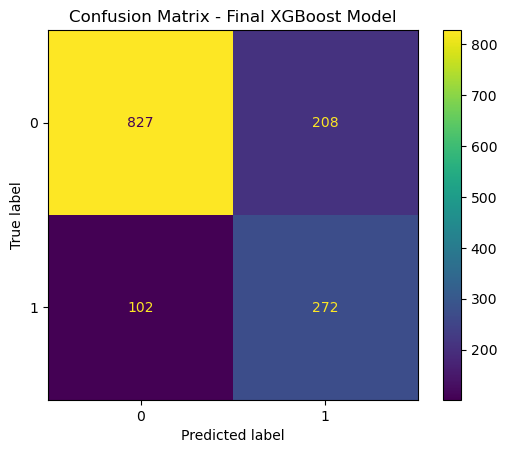

In [7]:
# Plot confusion matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix - Final XGBoost Model")

plt.savefig(
    "../images/confusion_matrix.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

# ROC Curve

Since XGBoost was selected partly because of ROC-AUC

Business meaning:

ROC curve shows how well the model separates:

customers who will churn
customers who will stay

The higher the ROC-AUC score, the better the model is at ranking high-risk customers above low-risk customers.

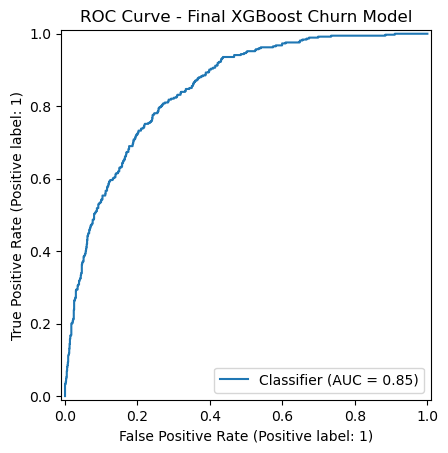

In [8]:
# Plot ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    "ROC Curve - Final XGBoost Churn Model"
)

plt.savefig(
    "../images/roc_curve.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

# Precision-Recall Curve

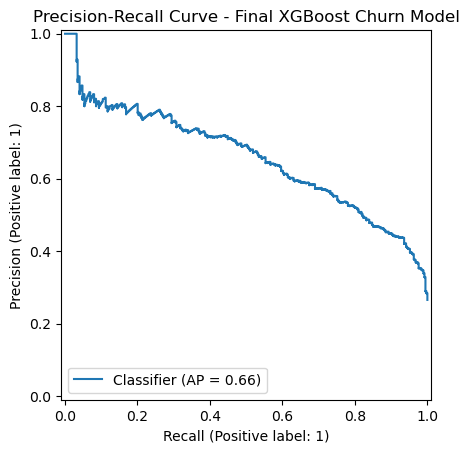

In [9]:
# Plot Precision-Recall Curve

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    "Precision-Recall Curve - Final XGBoost Churn Model"
)

plt.savefig(
    "../images/precision_recall_curve.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

# Feature Importance (Very important for XGBoost)

In [10]:
# Load the preprocessor
preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Extract XGBoost feature importances
feature_importance = final_model.named_steps[
    "classifier"
].feature_importances_

# Create DataFrame
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Sort by importance
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 20
importance.head(20)

,Feature,Importance
4,num__ContractMonths,0.330219
13,cat__InternetService_Fiber optic,0.172901
24,cat__TechSupport_No,0.055062
15,cat__OnlineSecurity_No,0.049196
14,cat__InternetService_No,0.031049
32,cat__StreamingMovies_Yes,0.026993
1,num__tenure,0.026735
39,cat__PaymentMethod_Electronic check,0.024399
12,cat__InternetService_DSL,0.023252
29,cat__StreamingTV_Yes,0.021193


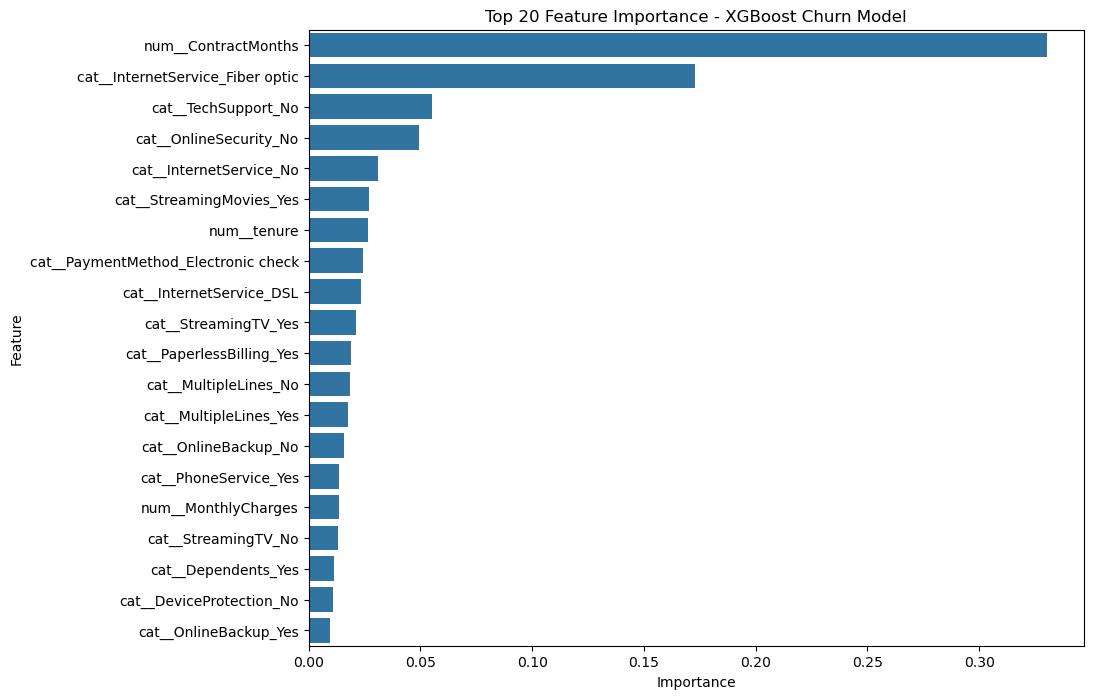

In [11]:
# Plot feature importance

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 20 Feature Importance - XGBoost Churn Model"
)

plt.xlabel("Importance")
plt.ylabel("Feature")


plt.savefig(
    "../images/feature_importance.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

# Saves

In [12]:
#  save final_evaluation_results

final_results.to_csv(
    "../reports/final_model_evaluation.csv",
    index=False
)

In [13]:
# Save Feature Importance Results

importance.to_csv(
    "../reports/xgboost_feature_importance.csv",
    index=False
)

In [14]:
# Save Classification Report

classification_results = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
).transpose()

classification_results.to_csv(
    "../reports/classification_report.csv"
)

# Business Interpretation

### Final Model Selection

After evaluating and optimizing multiple machine learning models, XGBoost was selected as the final production model for customer churn prediction.

Although Logistic Regression achieved the highest recall, XGBoost demonstrated the strongest overall predictive performance by achieving the highest ROC-AUC while maintaining competitive precision, recall, and F1 Score. This balance makes XGBoost more suitable for accurately identifying customers at risk of churning while minimizing unnecessary retention efforts.

Logistic Regression was retained as a benchmark model because of its excellent interpretability. Its coefficients provide clear insights into how different customer attributes influence churn, making it valuable for communicating model findings to business stakeholders and supporting explainable decision-making.

## Business Value

The selected XGBoost model enables the business to proactively identify customers who are at risk of leaving before churn occurs.

By predicting churn probabilities, the organization can:

Identify high-risk customers early.
Prioritize retention campaigns for customers most likely to leave.
Allocate marketing and customer support resources more efficiently.
Improve customer satisfaction through targeted interventions.
Reduce customer attrition and increase long-term customer lifetime value.

Rather than reacting after customers leave, the model allows the business to take preventive actions that strengthen customer relationships and improve revenue retention.

### Key Business Insights

The evaluation results suggest that customer churn is influenced by multiple customer characteristics and service-related factors.

Based on the model and earlier exploratory analysis, customers with the following characteristics are generally more likely to churn:

Short customer tenure.
Month-to-month contracts.
Higher monthly service charges.
Limited use of value-added support services.
Fiber optic internet customers without sufficient customer support.

These insights can help business leaders design more effective retention strategies targeted at customers with the highest likelihood of churning.

### Recommended Business Actions

Based on the model predictions, the following business strategies are recommended:

Develop proactive retention campaigns for customers identified as high risk.
Strengthen onboarding programs for new customers to improve early engagement.
Encourage customers to migrate from month-to-month contracts to longer-term plans through incentives.
Improve customer support services for high-risk customer segments.
Regularly monitor churn predictions and retrain the model as new customer data becomes available to maintain predictive performance.

### Conclusion

The optimized XGBoost model demonstrated the strongest overall predictive performance and was selected as the final production model for deployment.

By combining predictive analytics with targeted business interventions, the organization can identify customers likely to churn, improve customer retention, reduce revenue loss, and support data-driven decision-making.

Logistic Regression remains an important benchmark model because of its interpretability and its ability to explain the factors contributing to customer churn, providing additional value for business reporting and stakeholder communication.

# Feature Importance Analysis - Business Interpretation

The XGBoost model identified the following factors as the strongest predictors of customer churn.

## 1. Contract Type (Highest Impact Feature)

The most important feature was:

- ContractMonths (Importance: 33.02%)

This indicates that the length or type of customer contract has the strongest influence on churn prediction.

Customers with shorter-term commitments are more likely to churn because they have fewer barriers to switching providers.

### Business Recommendation:

"The Precision-Recall curve was analyzed because churn prediction is a positive-class focused problem. The model must identify customers likely to leave while maintaining efficient use of retention resources. A strong balance between precision and recall indicates that the model can support targeted customer retention campaigns without generating excessive false alerts."

The company should encourage customers to move from short-term contracts to longer-term plans by offering:
- loyalty incentives,
- discounts,
- contract upgrade benefits,
- improved long-term value propositions.

---

## 2. Internet Service Type

The second strongest predictor was:

- Fiber optic internet service (Importance: 17.29%)

Internet service type has a significant relationship with churn behavior. Fiber optic customers may have higher expectations regarding speed, reliability, pricing, and customer experience.

### Business Recommendation:
The company should:
- monitor satisfaction among fiber optic users,
- investigate service complaints,
- improve technical support response,
- ensure pricing aligns with perceived value.

---

## 3. Lack of Customer Support Services

Important churn predictors included:

- TechSupport_No (Importance: 5.51%)
- OnlineSecurity_No (Importance: 4.92%)
- OnlineBackup_No (Importance: 1.57%)

Customers without additional support services appear more likely to churn.

This suggests that customers who receive fewer value-added services may have weaker engagement with the company.

### Business Recommendation:
The company should:
- promote support packages,
- provide personalized service recommendations,
- proactively contact customers without support services.

---

## 4. Customer Tenure

Feature:

- tenure (Importance: 2.67%)

Although not the strongest feature, tenure remains an important churn indicator.

Customers with shorter relationships with the company may require additional attention to prevent early churn.

### Business Recommendation:
The company should strengthen:
- new customer onboarding,
- early engagement programs,
- first-year retention strategies.

---

## 5. Payment Behavior

Feature:

- PaymentMethod_Electronic check (Importance: 2.44%)

Payment method contributes to churn prediction, suggesting that payment experience may influence customer retention.

### Business Recommendation:
The company should:
- encourage convenient payment methods,
- simplify billing processes,
- identify customers experiencing payment friction.


# Overall Business Insight

The model indicates that churn is not caused by a single factor but by a combination of customer commitment level, service experience, and engagement.

The highest-risk customers are likely those who:
- have shorter contracts,
- use fiber optic services,
- lack technical support and additional services,
- have shorter tenure with the company.

By identifying these customers early, the business can implement targeted retention strategies before customers decide to leave.